# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('athlete_events.csv')

df['Medal'] = df['Medal'].fillna('No medal')

df.drop_duplicates(inplace=True)
df.dropna(subset=['Weight', 'Age', 'Height'], inplace=True)

columnas_a_descartar = ['ID', 'Name', 'Games', 'NOC', 'Event']
df = df.drop(columns=columnas_a_descartar)
df.reset_index(drop=True, inplace=True)
print(df.shape)
df.head()

(206152, 10)


,Sex,Age,Height,Weight,Team,Year,Season,City,Sport,Medal
0,M,24.0,180.0,80.0,China,1992,Summer,Barcelona,Basketball,No medal
1,M,23.0,170.0,60.0,China,2012,Summer,London,Judo,No medal
2,F,21.0,185.0,82.0,Netherlands,1988,Winter,Calgary,Speed Skating,No medal
3,F,21.0,185.0,82.0,Netherlands,1988,Winter,Calgary,Speed Skating,No medal
4,F,25.0,185.0,82.0,Netherlands,1992,Winter,Albertville,Speed Skating,No medal


**Hallazgos de la carga y limpieza:**
*   **Variables descartadas:** "ID" (es una clave primaria), "Name" (identificador único para casi cada fila), "Games" (información redundante contenida en Year y Season), "NOC" (redundante frente a Team) y "Event" (riesgo grave de fuga de datos, ya que el evento suele explicitar la categoría de peso del atleta, ej: "Men's Heavyweight").
*   Se descartaron los registros nulos en la variable objetivo "Weight" y numéricas clave como "Height" y "Age".

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

Cardinalidad de variables categóricas:
Sex         2
Team      660
Season      2
City       42
Sport      56
Medal       4
dtype: int64


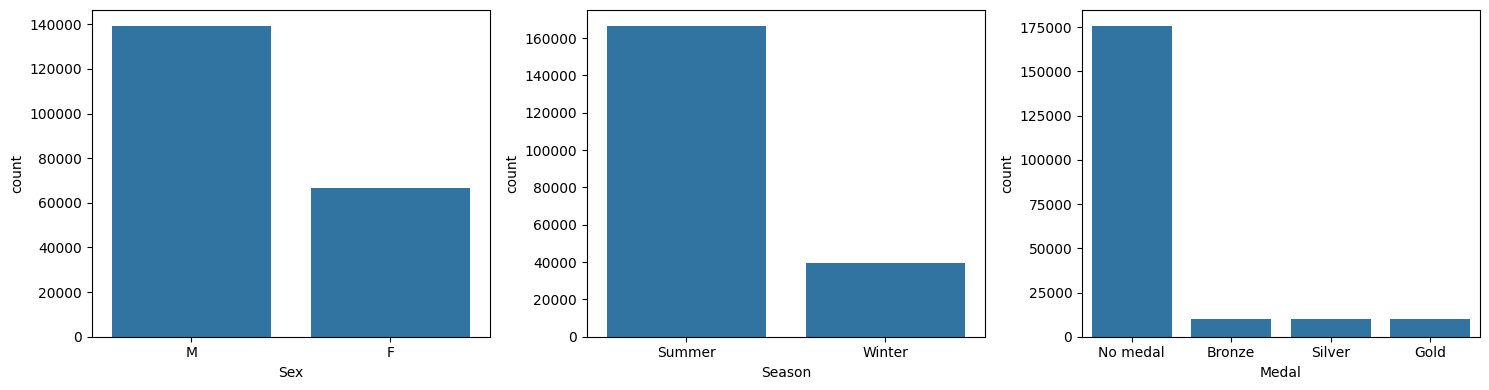

In [137]:
cat_cols = df.select_dtypes(include=['object']).columns

print("Cardinalidad de variables categóricas:")
print(df[cat_cols].nunique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='Sex', ax=axes[0])
sns.countplot(data=df, x='Season', ax=axes[1])
sns.countplot(data=df, x='Medal', order=['No medal', 'Bronze', 'Silver', 'Gold'], ax=axes[2])
plt.tight_layout()
plt.show()

**Hallazgos del análisis categórico:**

*   **Variables nominales:** Sex (2 categorías), Season (2 categorías), Team (660 categorías), City (42 categorías) y Sport (56 categorías).
*   **Variables ordinales:** Medal, ya que posee una jerarquía (No medal < Bronze < Silver < Gold).
*   **Alta cardinalidad:** Team tiene una altísima cardinalidad (660 valores). City y Sport tienen cardinalidad media-alta.
*   **Categorías atípicas/ruidosas:** Team agrupa nombres de países que a veces incluyen sufijos o años.

**Procesamiento propuesto:**
*   **Sex y Season:** Al ser nominales binarias, se procesarán con OneHotEncoder(drop='if_binary').
*   **Medal:** Se procesará con OrdinalEncoder respetando el orden lógico de la presea.
*   **Sport / City:** De usarse, se aplicarían con OneHotEncoder.
*   **Team:** descartar o agrupar debido a su altísima cardinalidad.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

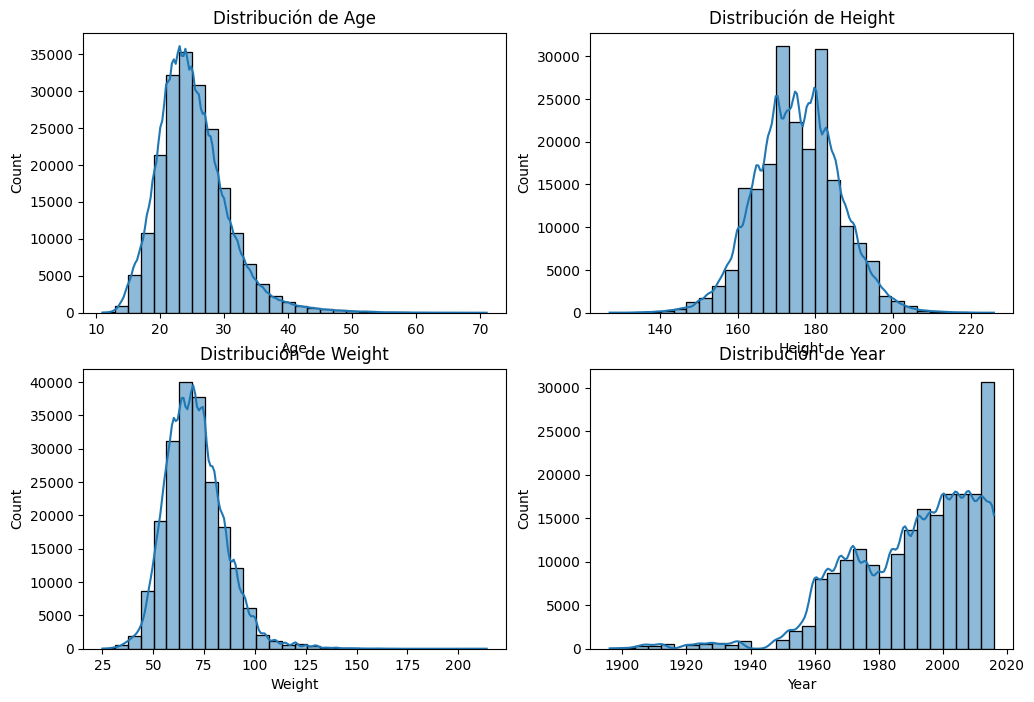

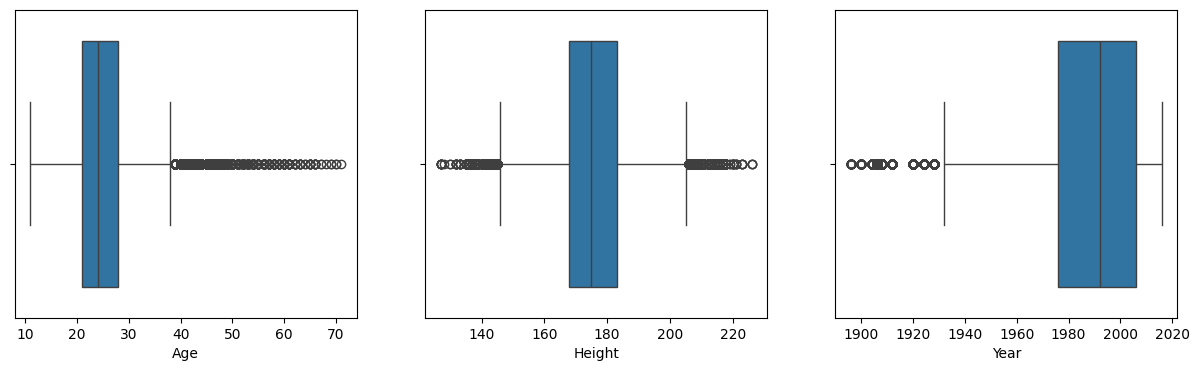

In [140]:
num_cols = ['Age', 'Height', 'Weight', 'Year']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df['Age'], ax=axes[0])
sns.boxplot(x=df['Height'], ax=axes[1])
sns.boxplot(x=df['Year'], ax=axes[2])
plt.show()

**Hallazgos del análisis cuantitativo:**

*   **Variables aproximadamente normales:** Height presenta una clara distribución normal o de campana de Gauss.
*   **Variables con datos atípicos:** Age muestra gran cantidad de valores atípicos (atletas de edades muy inusuales, superando los 50 o 60 años). Year presenta un comportamiento multimodal.

**Procesamiento propuesto:**
*   **Height:** Al tener comportamiento normal, se debe escalar con StandardScaler.
*   **Age:** Muchos outliers, se procesará con un PowerTransformer.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

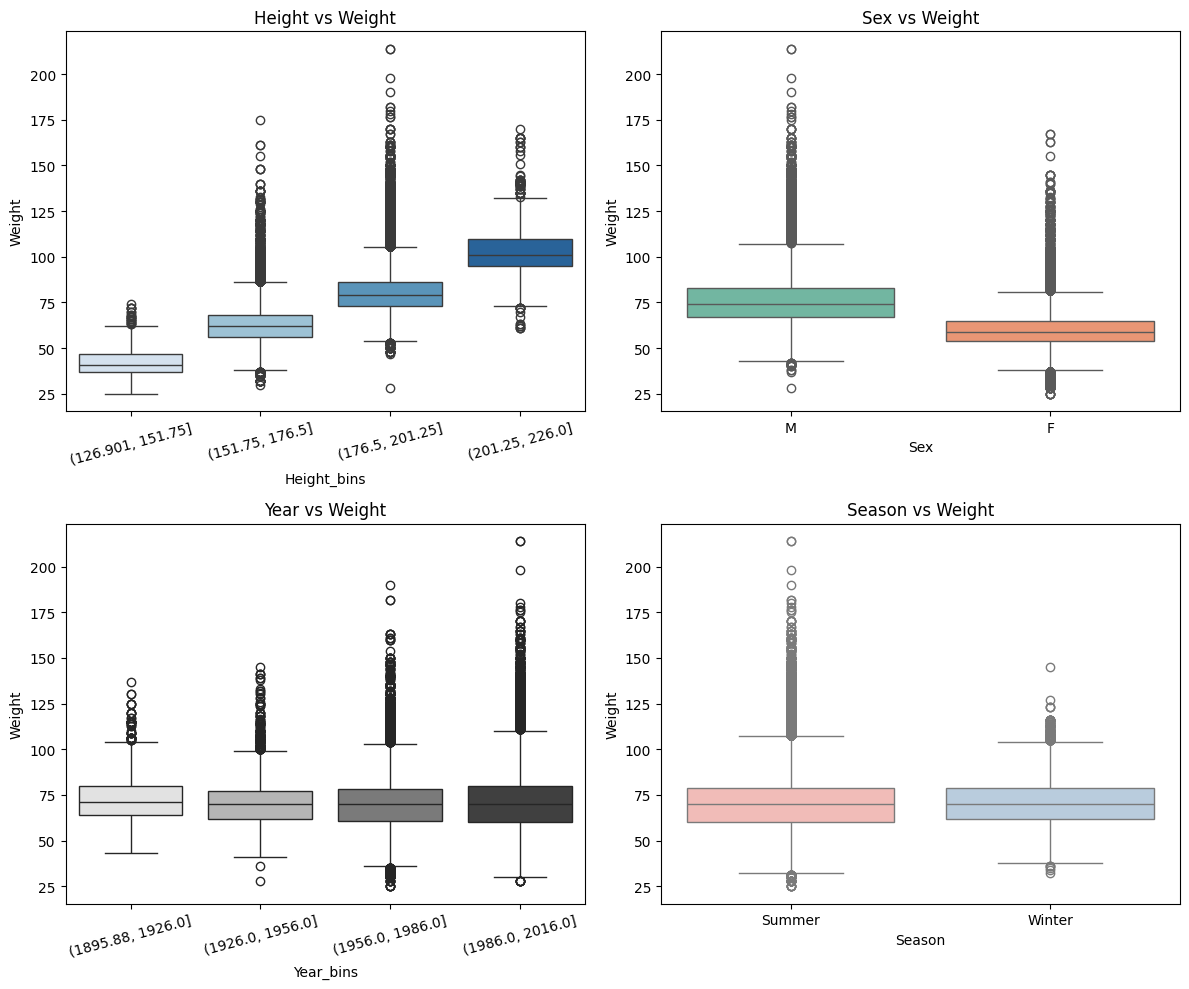

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df['Height_bins'] = pd.cut(df['Height'], bins=4)
sns.boxplot(x='Height_bins', y='Weight', data=df, ax=axes[0, 0], hue='Height_bins', palette='Blues', legend=False)
axes[0, 0].set_title('Height vs Weight')
axes[0, 0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Sex', y='Weight', data=df, ax=axes[0, 1], hue='Sex', palette='Set2', legend=False)
axes[0, 1].set_title('Sex vs Weight')

df['Year_bins'] = pd.cut(df['Year'], bins=4)
sns.boxplot(x='Year_bins', y='Weight', data=df, ax=axes[1, 0], hue='Year_bins', palette='Greys', legend=False)
axes[1, 0].set_title('Year vs Weight')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Season', y='Weight', data=df, ax=axes[1, 1], hue='Season', palette='Pastel1', legend=False)
axes[1, 1].set_title('Season vs Weight')

plt.tight_layout()
plt.show()

df.drop(['Height_bins', 'Year_bins'], axis=1, inplace=True)

**Hallazgos del análisis bivariado:**
*   **Variables potencialmente buenas predictoras:**
    *   Height: Al agruparla en rangos, muestra una relación directa y escalonada muy fuerte. A mayor estatura, el peso se incrementa notablemente de manera consistente.
    *   Sex: Muestra una separación clara. La mediana y la dispersión del peso en hombres son significativamente mayores que en las mujeres, lo que ayuda al modelo a hacer diferenciaciones.

*   **Variables potencialmente malas predictoras:**
    *   Year: El diagrama de cajas muestra que el peso promedio de los atletas se ha mantenido prácticamente constante a lo largo de las décadas.
    *   Season: Las distribuciones de peso para juegos de invierno (Winter) y verano (Summer) son casi idénticas, demostrando que la temporada no es un factor que determine el peso por sí sola.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

X = df.drop('Weight', axis=1)
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

ordinal_feat = ['Medal']
nominal_feat = ['Sex', 'Season']
num_feat_1 = ['Height']
num_feat_2 = ['Age']

ore = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']], dtype='int')
ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
ss = StandardScaler()
pt = PowerTransformer()

preprocessor = ColumnTransformer(transformers=[
    ('medal', ore, ordinal_feat),
    ('nominals', ohe, nominal_feat),
    ('height', ss, num_feat_1),
    ('age', pt, num_feat_2)
], remainder='drop')

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=1))
])

pipeline.fit(X_train, y_train)

print(f"Score de Entrenamiento (Ridge): {pipeline.score(X_train, y_train):.4f}")
print(f"Score de Prueba (Ridge): {pipeline.score(X_test, y_test):.4f}")

print("\nCaracterísticas resultantes del paso de procesamiento:")
print(preprocessor.get_feature_names_out())

Score de Entrenamiento (Ridge): 0.6628
Score de Prueba (Ridge): 0.6647

Características resultantes del paso de procesamiento:
['medal__Medal' 'nominals__Sex_M' 'nominals__Season_Winter'
 'height__Height' 'age__Age']


Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [143]:
nominal_feat_2 = ['Sex', 'Season', 'Sport']
num_feat_year = ['Height', 'Year']

preprocessor_2 = ColumnTransformer(transformers=[
    ('medal', ore, ordinal_feat),
    ('nominals', ohe, nominal_feat_2),
    ('height_year', ss, num_feat_year),
    ('age', pt, num_feat_2)
], remainder='drop')

pipeline_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('model', Ridge(random_state=1))
])

pipeline_2.fit(X_train, y_train)

print(f"Nuevo Score de Entrenamiento (Ridge): {pipeline_2.score(X_train, y_train):.4f}")
print(f"Nuevo Score de Prueba (Ridge): {pipeline_2.score(X_test, y_test):.4f}")

columnas_finales = preprocessor_2.get_feature_names_out()
print(f"Total de características: {len(columnas_finales)}")
print(columnas_finales)

Nuevo Score de Entrenamiento (Ridge): 0.7298
Nuevo Score de Prueba (Ridge): 0.7324
Total de características: 62
['medal__Medal' 'nominals__Sex_M' 'nominals__Season_Winter'
 'nominals__Sport_Alpine Skiing' 'nominals__Sport_Archery'
 'nominals__Sport_Art Competitions' 'nominals__Sport_Athletics'
 'nominals__Sport_Badminton' 'nominals__Sport_Baseball'
 'nominals__Sport_Basketball' 'nominals__Sport_Beach Volleyball'
 'nominals__Sport_Biathlon' 'nominals__Sport_Bobsleigh'
 'nominals__Sport_Boxing' 'nominals__Sport_Canoeing'
 'nominals__Sport_Cross Country Skiing' 'nominals__Sport_Curling'
 'nominals__Sport_Cycling' 'nominals__Sport_Diving'
 'nominals__Sport_Equestrianism' 'nominals__Sport_Fencing'
 'nominals__Sport_Figure Skating' 'nominals__Sport_Football'
 'nominals__Sport_Freestyle Skiing' 'nominals__Sport_Golf'
 'nominals__Sport_Gymnastics' 'nominals__Sport_Handball'
 'nominals__Sport_Hockey' 'nominals__Sport_Ice Hockey'
 'nominals__Sport_Judo' 'nominals__Sport_Lacrosse' 'nominals__Spor